### Libraries

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import warnings

from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, make_scorer, roc_auc_score, confusion_matrix, classification_report, precision_recall_curve, PrecisionRecallDisplay

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import sklearn

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.inspection import permutation_importance
from sklearn.ensemble import VotingClassifier
from sklearn.mixture import GaussianMixture

plt.rcParams.update({'font.size': 15})

### Data Exploration

In [2]:
df = pd.read_csv("heart.csv")

In [3]:
def resumetable(df):
    print(f"data shape: {df.shape}")
    summary = pd.DataFrame(df.dtypes, columns = ['data type'])
    summary = summary.reset_index()
    summary = summary.rename(columns = {"index": "feature"})
    summary["Num_Null"] = df.isnull().sum().values
    summary["Num_Unique"] = df.nunique().values
    summary["First_Value"] = df.loc[0].values
    summary["Second_Value"] = df.loc[1].values
    summary["Third_Value"] = df.loc[2].values
    
    return summary

In [4]:
resumetable(df)

data shape: (918, 12)


,feature,data type,Num_Null,Num_Unique,First_Value,Second_Value,Third_Value
0,Age,int64,0,50,40,49,37
1,Sex,object,0,2,M,F,M
2,ChestPainType,object,0,4,ATA,NAP,ATA
3,RestingBP,int64,0,67,140,160,130
4,Cholesterol,int64,0,222,289,180,283
5,FastingBS,int64,0,2,0,0,0
6,RestingECG,object,0,3,Normal,Normal,ST
7,MaxHR,int64,0,119,172,156,98
8,ExerciseAngina,object,0,2,N,N,N
9,Oldpeak,float64,0,53,0.0,1.0,0.0


- No Null data
- Categorical features: Sex, ChestPainType, FastingBS, RestingECG, ExerciseAnigma, ST_slope
- Numerical features: Age, RestingBP, Cholesterol, MaxHR, Oldpeak 

In [5]:
numeric = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
df_num = df[numeric]
df_num.head()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
0,40,140,289,172,0.0
1,49,160,180,156,1.0
2,37,130,283,98,0.0
3,48,138,214,108,1.5
4,54,150,195,122,0.0


In [6]:
categorical = [col for col in df.columns if col not in numeric + ["HeartDisease"]]
df_cat = df[categorical]
df_cat.head()

,Sex,ChestPainType,FastingBS,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,0,Normal,N,Up
1,F,NAP,0,Normal,N,Flat
2,M,ATA,0,ST,N,Up
3,F,ASY,0,Normal,Y,Flat
4,M,NAP,0,Normal,N,Up


In [7]:
df_cat.nunique().sort_values(ascending=True)

Sex               2
FastingBS         2
ExerciseAngina    2
RestingECG        3
ST_Slope          3
ChestPainType     4
dtype: int64

# Explaratory Data Analysis (EDA)

In [8]:
def write_percent(ax, total_size):
    """
    Iterates over shape objects and 
    displays the target value ratio at the top of each bar
    """
    for patch in ax.patches:
        height = patch.get_height()
        width = patch.get_width()
        left_coord = patch.get_x()
        percent = height/total_size * 100

        ax.text(x = left_coord + width/2.0,
                y = height + total_size * 0.001,
                s = f"{percent: 1.1f}%",
                ha = "center")

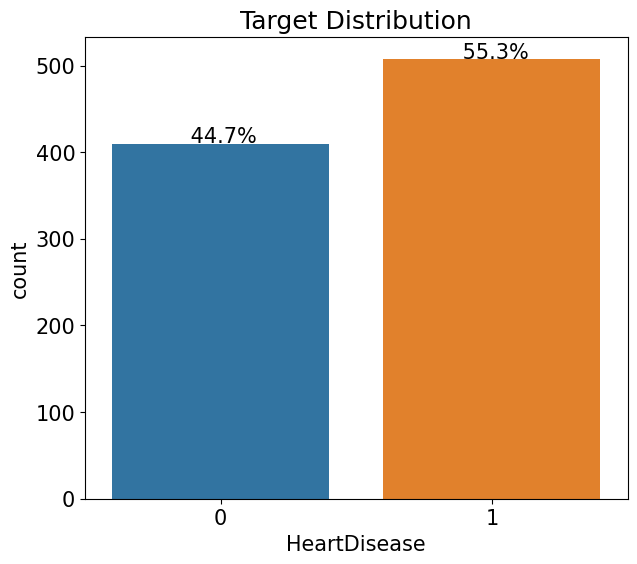

In [9]:
plt.figure(figsize = (7, 6))

ax = sns.countplot(x = "HeartDisease", data = df)
write_percent(ax, len(df))
ax.set_title("Target Distribution");

- Pretty balanced target distribution 

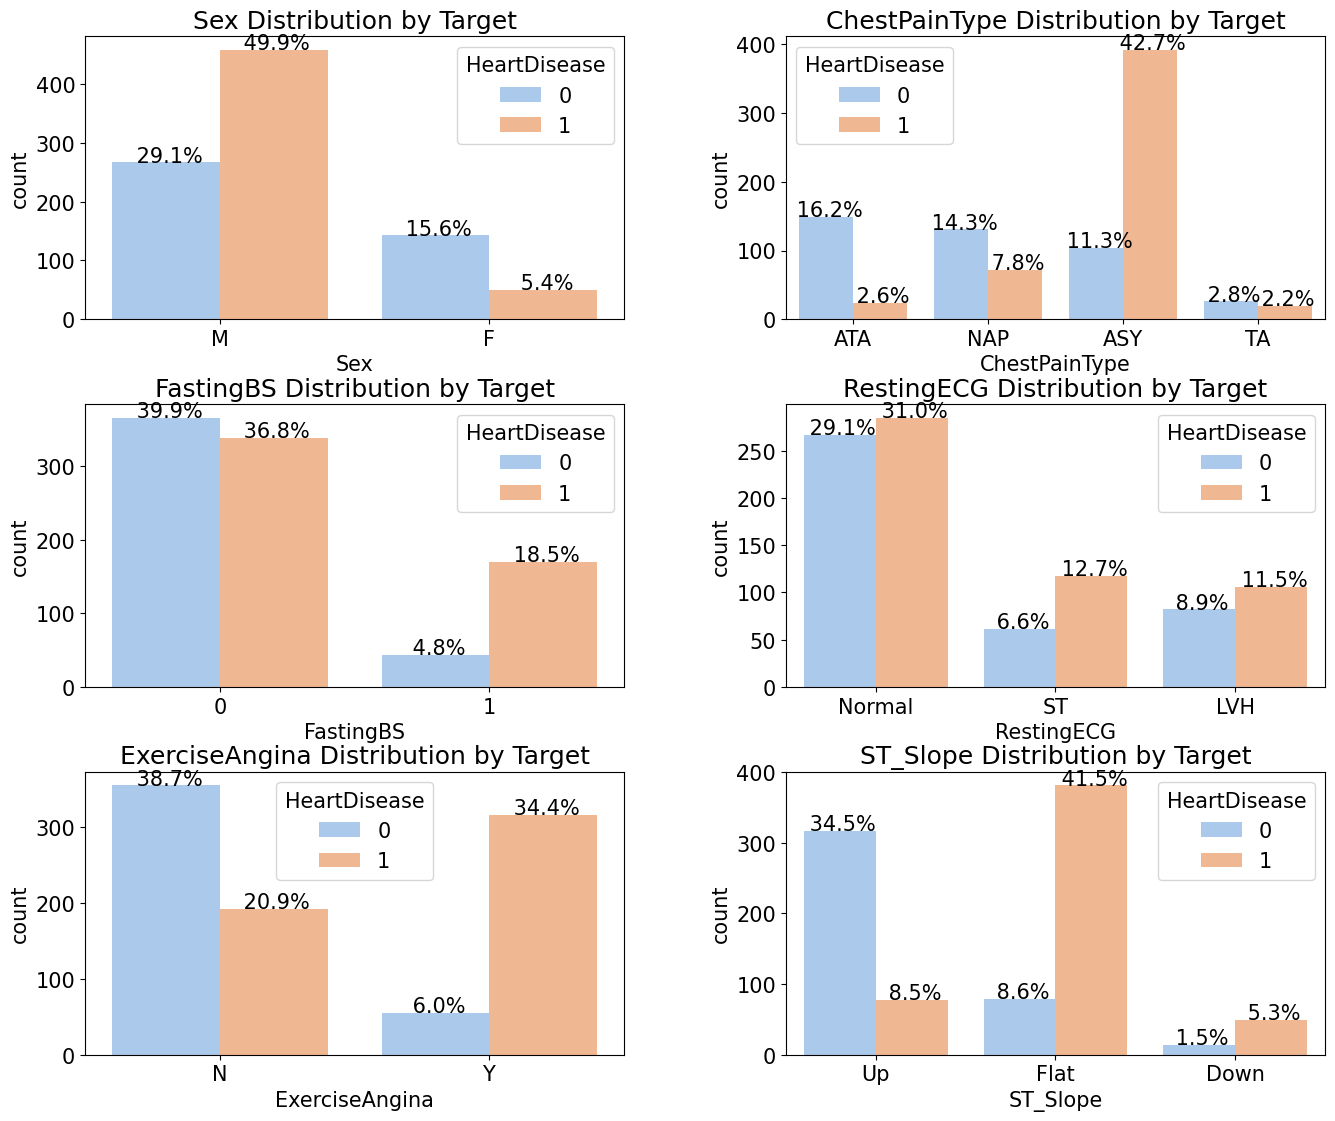

In [10]:
# Categorical Feature distribution

# mpl.rc("font", size = 12)
grid = gridspec.GridSpec(4, 2) 
plt.figure(figsize = (16, 18))
plt.subplots_adjust(wspace = 0.3, hspace = 0.3)

for idx, feature in enumerate(categorical):
    ax = plt.subplot(grid[idx])
    sns.countplot(x = feature, data = df, hue = "HeartDisease", palette = "pastel", ax = ax)
    ax.set_title(f"{feature} Distribution by Target")
    write_percent(ax, len(df))

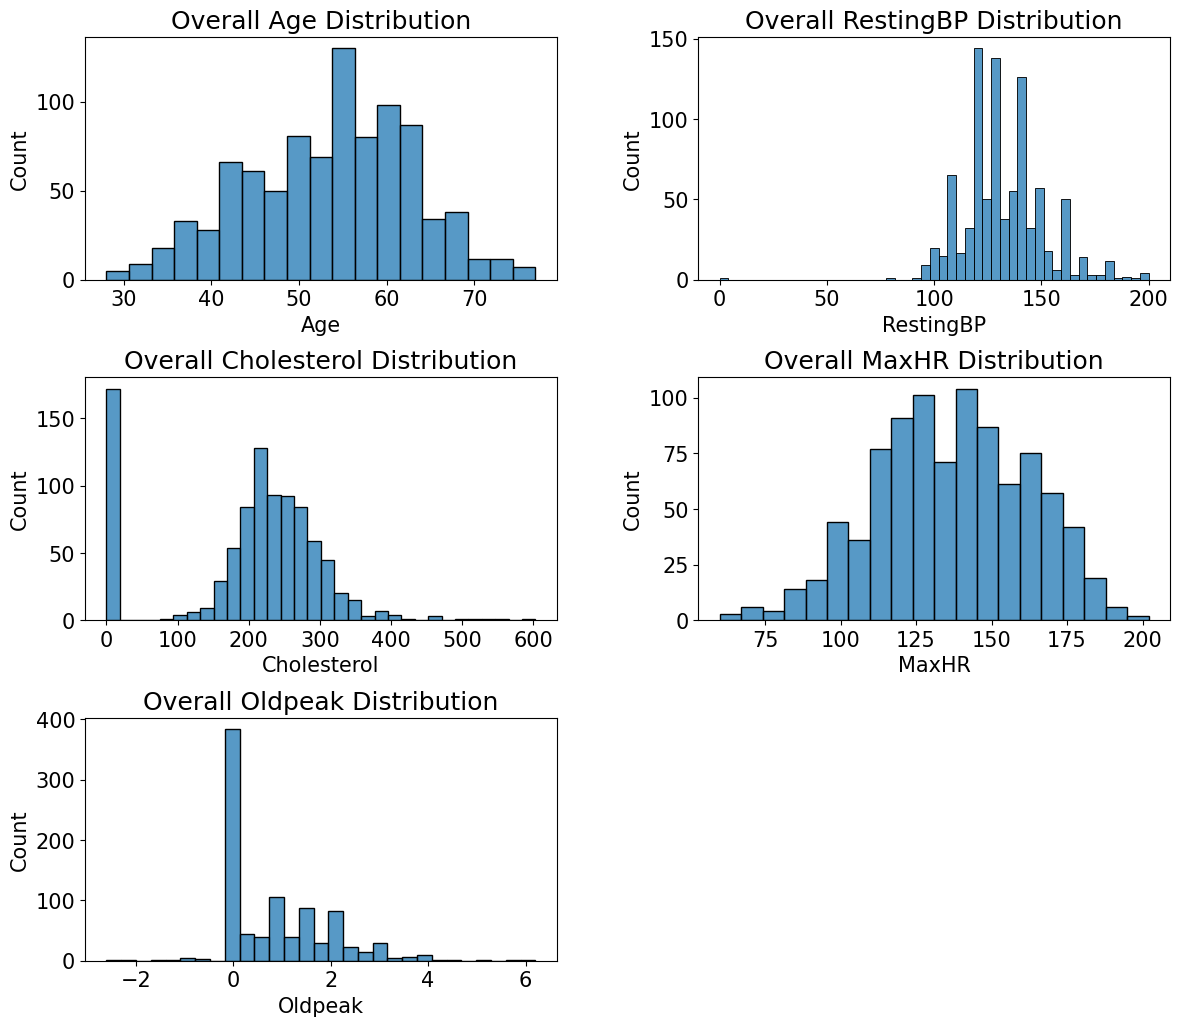

In [11]:
# Numerical Feature Distribution
warnings.filterwarnings('ignore', category=FutureWarning)

fig = plt.figure(figsize=(14, 12))
grid = gridspec.GridSpec(3, 2, figure=fig)
plt.subplots_adjust(wspace=0.3, hspace=0.4)

for idx, feature in enumerate(numeric):
    ax = plt.subplot(grid[idx])
    sns.histplot(data = df, x = feature, kde = False, ax = ax)
    ax.set_title(f"Overall {feature} Distribution")
    ax.set_xlabel(feature);

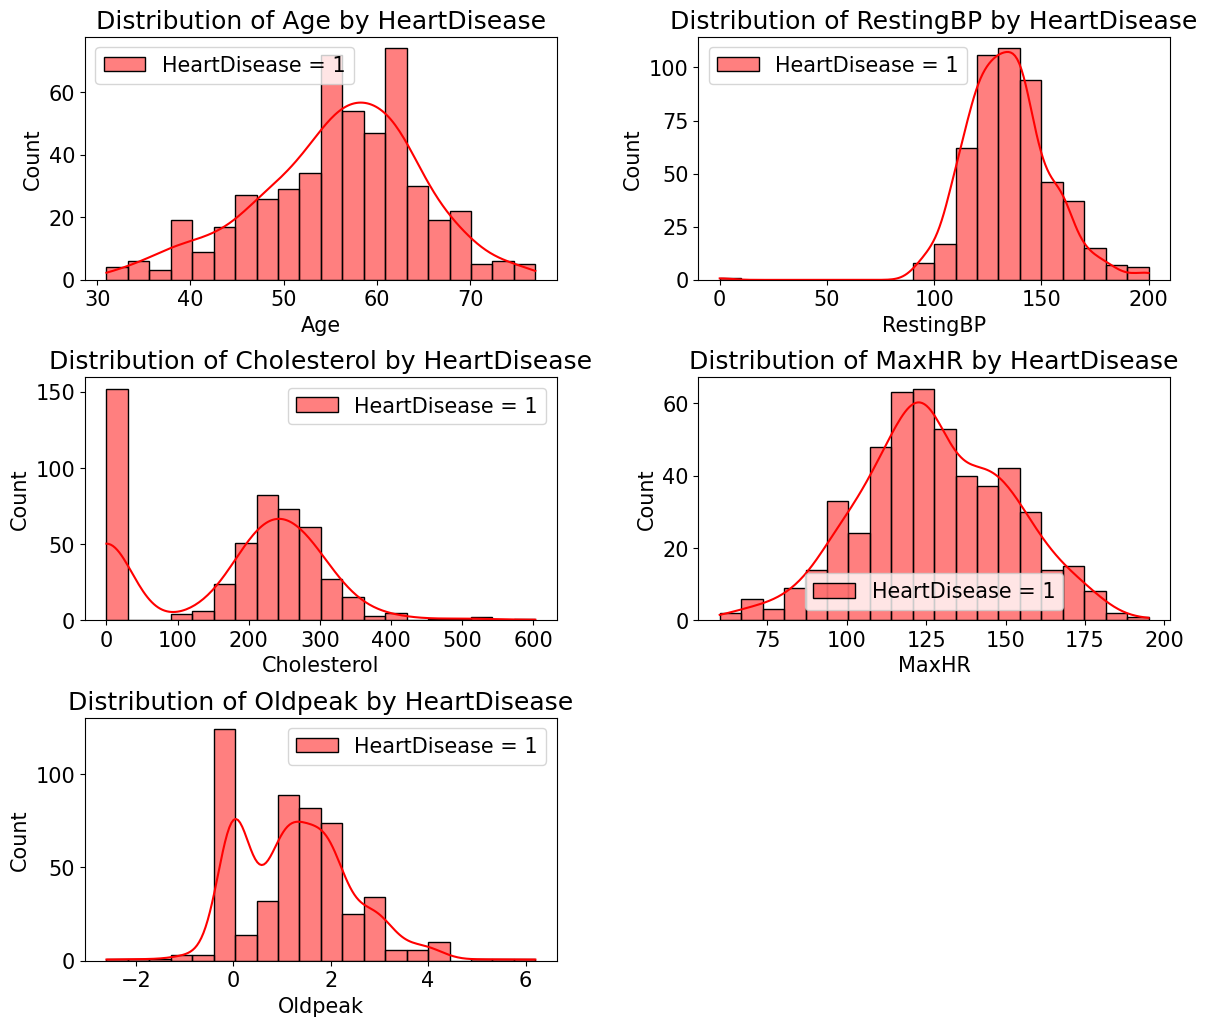

In [12]:
fig = plt.figure(figsize=(14, 12))
grid = gridspec.GridSpec(3, 2, figure=fig)
plt.subplots_adjust(wspace=0.3, hspace=0.4)

for idx, feature in enumerate(numeric):
    ax = plt.subplot(grid[idx])
    sns.histplot(df[df['HeartDisease'] == 1][feature], kde=True, color='red', label='HeartDisease = 1', bins=20, ax=ax)
    ax.set_title(f"Distribution of {feature} by HeartDisease")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")
    ax.legend();

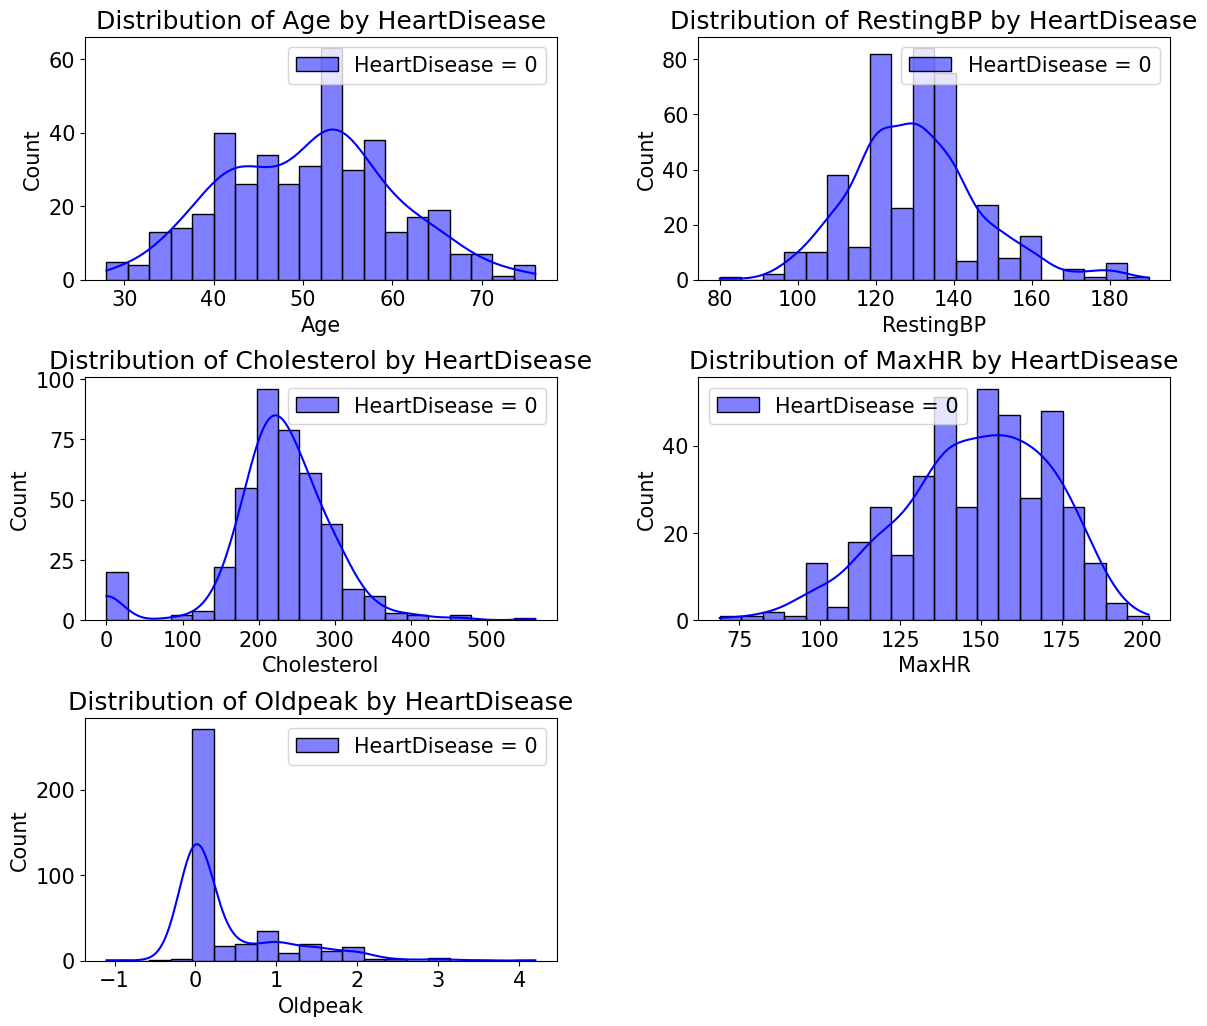

In [13]:
fig = plt.figure(figsize=(14, 12))
grid = gridspec.GridSpec(3, 2, figure=fig)
plt.subplots_adjust(wspace=0.3, hspace=0.4)

for idx, feature in enumerate(numeric):
    ax = plt.subplot(grid[idx])
    sns.histplot(df[df['HeartDisease'] == 0][feature], kde = True, color = 'b', bins=20, label = 'HeartDisease = 0', ax = ax)
    ax.set_title(f"Distribution of {feature} by HeartDisease")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")
    ax.legend();

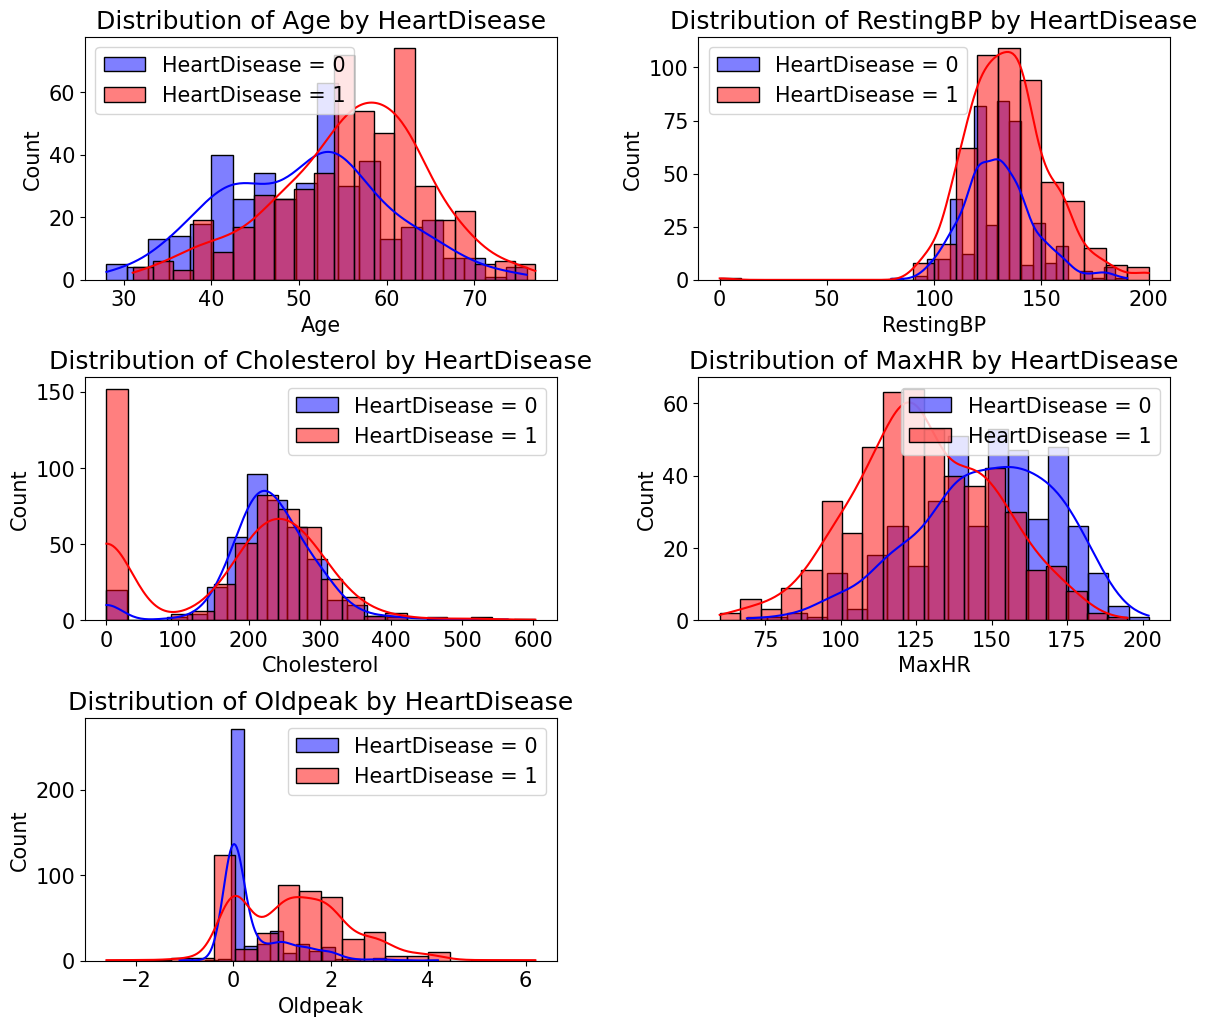

In [14]:
fig = plt.figure(figsize=(14, 12))
grid = gridspec.GridSpec(3, 2, figure=fig)
plt.subplots_adjust(wspace=0.3, hspace=0.4)

for idx, feature in enumerate(numeric):
    ax = plt.subplot(grid[idx])
    sns.histplot(df[df['HeartDisease'] == 0][feature], kde = True, color = 'b', bins=20, label = 'HeartDisease = 0', ax = ax)
    sns.histplot(df[df['HeartDisease'] == 1][feature], kde = True, color = 'red', bins=20, label = 'HeartDisease = 1', ax = ax)
    ax.set_title(f"Distribution of {feature} by HeartDisease")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")
    ax.legend();

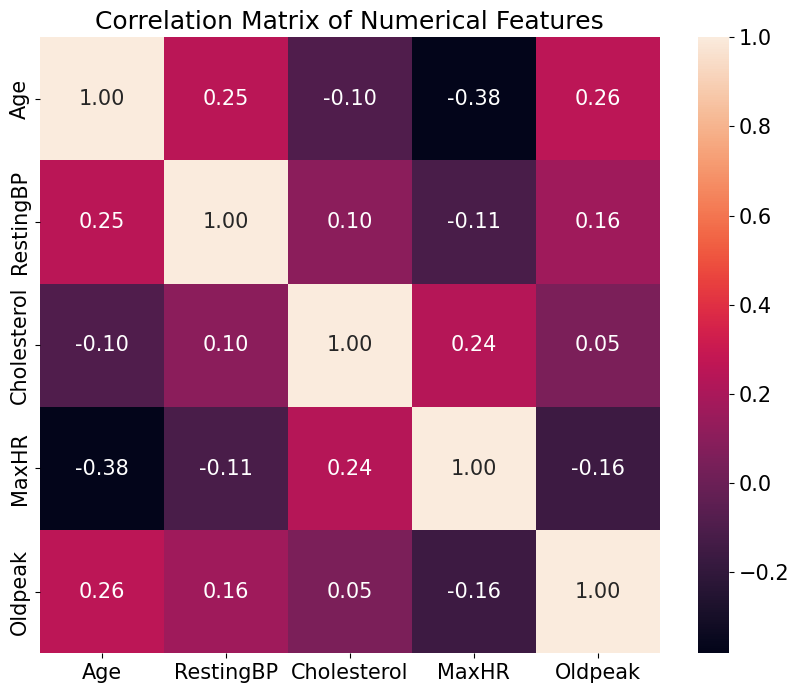

In [15]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric].corr(), annot = True, fmt=".2f")
plt.title("Correlation Matrix of Numerical Features");

# Data Preprocessing

In [11]:
chol_median = df[df['Cholesterol'] > 0]['Cholesterol'].median()
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)
df['Cholesterol'] = df['Cholesterol'].fillna(chol_median)
df['Cholesterol_Log'] = np.log(df['Cholesterol'])
df.drop('Cholesterol', axis=1, inplace=True)

In [12]:
df['RestingBP'] = df['RestingBP'].replace(0, np.nan)
bp_median = df['RestingBP'].median()
df['RestingBP'] = df['RestingBP'].fillna(bp_median)

In [13]:
df['Oldpeak'] = df['Oldpeak'].clip(lower=0)

# Featrue Engineering

In [14]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

In [15]:
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=.2, random_state=0, stratify=y)
X_valid, X_test, y_valid, y_test = train_test_split(X_tmp, y_tmp, test_size=.5, random_state=0, stratify=y_tmp)

print(f"Train set shape: {X_train.shape}")
print(f"Validation set shape: {X_valid.shape}")
print(f"Test set shape: {X_test.shape}")

Train set shape: (734, 11)
Validation set shape: (92, 11)
Test set shape: (92, 11)


In [16]:
numeric_features = ['Age', 'RestingBP', 'Cholesterol_Log', 'MaxHR', 'Oldpeak']
categorical_features = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

In [17]:
preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_features),
                  ('cat', OneHotEncoder(handle_unknown = 'ignore', drop = 'first'), categorical_features)],
    remainder='drop')

In [18]:
X_train_processed = preprocessor.fit_transform(X_train)
transformed_feature_names = preprocessor.get_feature_names_out()

print("Preprocessed training data shape:", X_train_processed.shape)

Preprocessed training data shape: (734, 15)


# Feature selection

In [19]:
selector = SelectKBest(score_func = f_classif, k = 5)
selector.fit(X_train_processed, y_train)

selected_indices = selector.get_support(indices=True)
selected_features = [transformed_feature_names[i] for i in selected_indices]

all_feature_scores = pd.DataFrame({
    'Feature': transformed_feature_names,
    'Score': selector.scores_})

selected_feature_scores = all_feature_scores.iloc[selected_indices].sort_values('Score', ascending=False)

In [20]:
print("\nTop 5 Features selected by SelectKBest (on preprocessed data):")
print(selected_feature_scores)


Top 5 Features selected by SelectKBest (on preprocessed data):
                  Feature       Score
14       cat__ST_Slope_Up  459.853278
13     cat__ST_Slope_Flat  327.247000
12  cat__ExerciseAngina_Y  245.201809
4            num__Oldpeak  153.399776
3              num__MaxHR  148.389263


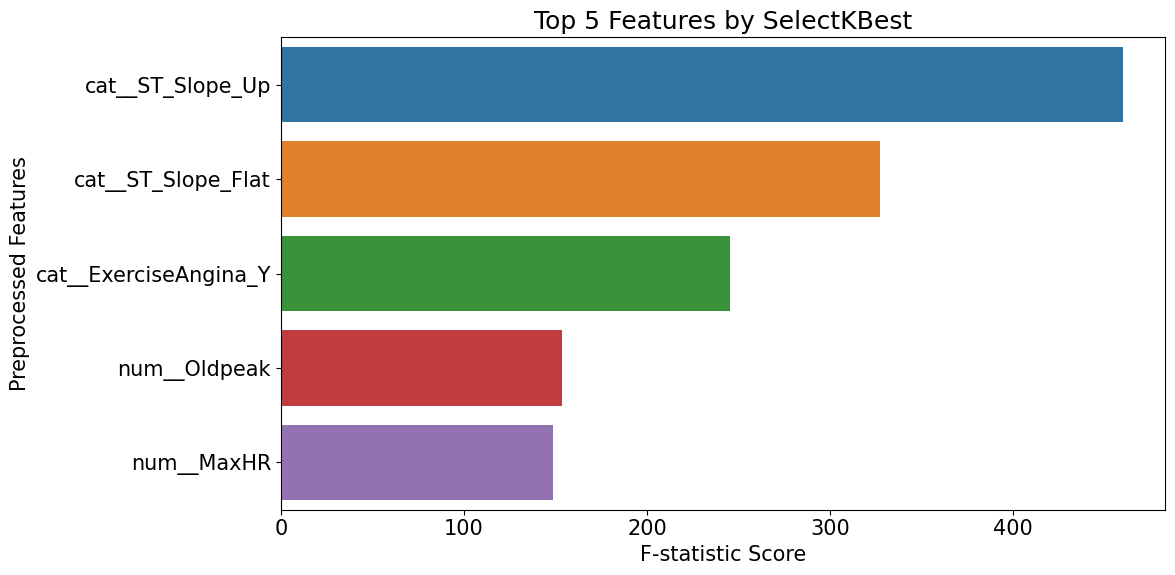

In [21]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Score', y='Feature', data=selected_feature_scores)
plt.title('Top 5 Features by SelectKBest')
plt.xlabel('F-statistic Score')
plt.ylabel('Preprocessed Features')
plt.tight_layout();

# Modeling

In [22]:
models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('selector', SelectKBest(score_func = f_classif, k = 5)),
        ('classifier', LogisticRegression(max_iter=1000))]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('selector', SelectKBest(score_func = f_classif, k = 5)),
        ('classifier', RandomForestClassifier(random_state=42))]),
    'SVM': Pipeline([
        ('preprocessor', preprocessor),
        ('selector', SelectKBest(score_func = f_classif, k = 5)),
        ('classifier', SVC(probability=True, random_state=42))])}

In [69]:
results = {}
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_valid)
    
    results[name] = {
        'accuracy': accuracy_score(y_valid, y_pred),
        'precision': precision_score(y_valid, y_pred),
        'recall': recall_score(y_valid, y_pred),
        'f1': f1_score(y_valid, y_pred),
        'roc_auc': roc_auc_score(y_valid, pipeline.predict_proba(X_valid)[:,1])}

In [70]:
results_df = pd.DataFrame(results).T
print(results_df)

                     accuracy  precision    recall        f1   roc_auc
Logistic Regression  0.869565   0.933333  0.823529  0.875000  0.913439
Random Forest        0.782609   0.816327  0.784314  0.800000  0.884983
SVM                  0.869565   0.914894  0.843137  0.877551  0.895265
[CV] END classifier__C=1000, classifier__gamma=0.1, classifier__kernel=linear; total time= 1.4min
[CV] END classifier__C=1000, classifier__gamma=0.0001, classifier__kernel=linear; total time= 1.0min
[CV] END classifier__C=1000, classifier__gamma=0.001, classifier__kernel=rbf; total time=   0.1s
[CV] END classifier__C=1000, classifier__gamma=0.1, classifier__kernel=linear; total time=  59.5s
[CV] END classifier__C=1000, classifier__gamma=1, classifier__kernel=linear; total time= 1.4min
[CV] END classifier__C=10, classifier__gamma=0.01, classifier__kernel=linear; total time=   0.0s
[CV] END classifier__C=10, classifier__gamma=0.01, classifier__kernel=linear; total time=   0.0s
[CV] END classifier__C=10, class

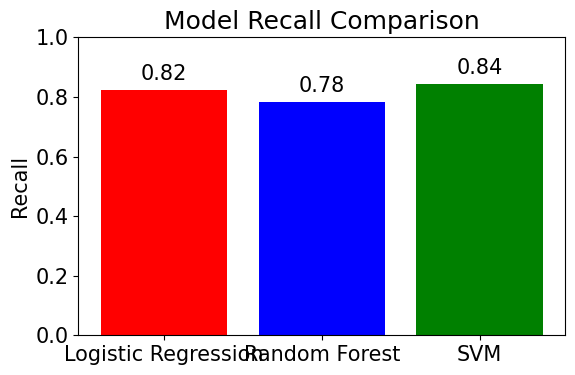

In [25]:
models_name = results_df.index.tolist()
recalls = results_df['recall'].values

mpl.rc("font", size=15)
plt.figure(figsize=(6, 4))
bars = plt.bar(models_name, recalls, color = ['red', 'blue', 'green'])

for bar, recall in zip(bars, recalls):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{recall:.2f}", 
             ha='center', va='bottom')

plt.ylabel('Recall')
plt.title('Model Recall Comparison')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout();

In [26]:
best_model_name = results_df['recall'].idxmax()
print(f"Best model based on Recall score: {best_model_name}")

Best model based on Recall score: SVM


# Hyperparameter Tuning + Evaluation

In [57]:
if best_model_name == 'Logistic Regression':
    param_grid = {'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
                  'classifier__penalty': ['l1', 'l2', 'elasticnet', None],
                  'classifier__solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']}
elif best_model_name == 'Random Forest':
    param_grid = {'classifier__n_estimators': [100, 200, 300],
                  'classifier__max_depth': [None, 5, 10, 15],
                  'classifier__min_samples_split': [2, 5, 10],
                  'classifier__min_samples_leaf': [1, 2, 4]}
else:  
    param_grid = {'classifier__C': [0.1, 1, 10, 100, 1000],  
                  'classifier__gamma': ['scale', 1, 0.1, 0.01, 0.001, 0.0001],
                  'classifier__kernel': ['linear', 'rbf']}

In [58]:
fbeta_scorer = make_scorer(fbeta_score, beta=2)

# grid_search = GridSearchCV(models[best_model_name],
#                            param_grid, 
#                            cv = 5, 
#                            scoring = fbeta_scorer, 
#                            n_jobs = -1)

random_search = RandomizedSearchCV(
    estimator = models[best_model_name],
    param_distributions = param_grid,   
    n_iter = 50,                        
    cv = 5,
    scoring = fbeta_scorer,
    n_jobs = -1,
    verbose = 2)

In [59]:
random_search.fit(X_train, y_train)
print("Best model:", best_model_name)
print("Best parameters:", random_search.best_params_)
best_model = random_search.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best model: SVM
Best parameters: {'classifier__kernel': 'rbf', 'classifier__gamma': 1, 'classifier__C': 0.1}


In [60]:
y_pred_tuned = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_tuned))

final_results = {
    'accuracy': accuracy_score(y_test, y_pred_tuned),
    'precision': precision_score(y_test, y_pred_tuned),
    'recall': recall_score(y_test, y_pred_tuned),
    'f1': f1_score(y_test, y_pred_tuned),
    'roc_auc': roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1])}

              precision    recall  f1-score   support

           0       0.89      0.76      0.82        41
           1       0.82      0.92      0.87        51

    accuracy                           0.85        92
   macro avg       0.86      0.84      0.84        92
weighted avg       0.85      0.85      0.85        92



In [73]:
print("\nFinal Model Evaluation on Test Set:")
for metric, value in final_results.items():
    print(f"{metric}: {value:.4f}")


Final Model Evaluation on Test Set:
accuracy: 0.8478
precision: 0.8246
recall: 0.9216
f1: 0.8704
roc_auc: 0.9072


### Threshold Optimization

In [51]:
# thresholds = np.arange(0.1, 0.95, 0.01)
# f1_scores = []

# for thresh in thresholds:
#     y_pred_thresh = (y_pred_proba >= thresh).astype(int)
#     f1 = f1_score(y_test, y_pred_thresh)
#     f1_scores.append(f1)
#     print(f"Threshold: {thresh:.2f}, F1-Score: {f1:.4f}")

# optimal_thresh = thresholds[np.argmax(f1_scores)]

AttributeError: module 'numpy' has no attribute 'arnage'

In [ ]:
# y_pred_custom = (y_pred_proba >= optimal_thresh).astype(int)
# auc_score = roc_auc_score(y_test, y_pred_custom)

# print(f"Optimal Threshold: {optimal_thresh:.3}")
# print("ROC-AUC Score (RandomSearchCV):", auc_score)
# print("Classification Report:\n", classification_report(y_test, y_pred_custom))

# Evaluation

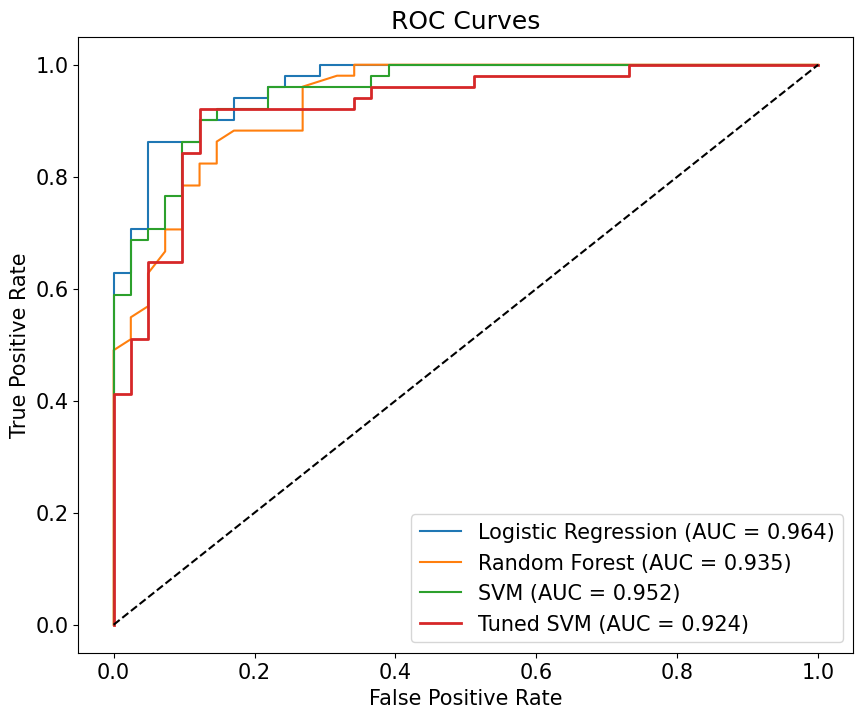

In [36]:
# plt.figure(figsize=(10, 8))
# for name, pipeline in models.items():
#     y_probs = pipeline.predict_proba(X_test)[:,1]
#     fpr, tpr, _ = sklearn.metrics.roc_curve(y_test, y_probs)
#     auc = roc_auc_score(y_test, y_probs)
#     plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

# y_probs_tuned = best_model.predict_proba(X_test)[:,1]
# fpr_tuned, tpr_tuned, _ = sklearn.metrics.roc_curve(y_test, y_probs_tuned)
# auc_tuned = roc_auc_score(y_test, y_probs_tuned)
# plt.plot(fpr_tuned, tpr_tuned, linewidth=2, 
#          label=f"Tuned {best_model_name} (AUC = {auc_tuned:.3f})")

# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('ROC Curves')
# plt.legend();

# Feature importance

In [37]:
lr = Pipeline([('preprocessor', preprocessor), 
               ('classifier', LogisticRegression(max_iter=1000))])
rf = Pipeline([('preprocessor', preprocessor), 
               ('classifier', RandomForestClassifier(random_state=42))])
svm = Pipeline([('preprocessor', preprocessor), 
                ('classifier', SVC(probability=True, random_state=42))])

In [38]:
voting_clf = VotingClassifier(
    estimators=[('lr', lr), ('rf', rf), ('svm', svm)],
    voting = 'soft')

In [39]:
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('lr',
                              Pipeline(steps=[('preprocessor',
                                               ColumnTransformer(transformers=[('num',
                                                                                StandardScaler(),
                                                                                ['Age',
                                                                                 'RestingBP',
                                                                                 'Cholesterol_Log',
                                                                                 'MaxHR',
                                                                                 'Oldpeak']),
                                                                               ('cat',
                                                                                OneHotEncoder(drop='first',
                                                                                              handle_unknown='ignore'),
                                                                                ['Sex',
                                                                                 'ChestPainType',
                                                                                 'FastingBS',
                                                                                 'RestingECG',
                                                                                 'ExerciseAngina',
                                                                                 'ST_Slope'])])),
                                              ('classifier',
                                               LogisticRegressi...
                              Pipeline(steps=[('preprocessor',
                                               ColumnTransformer(transformers=[('num',
                                                                                StandardScaler(),
                                                                                ['Age',
                                                                                 'RestingBP',
                                                                                 'Cholesterol_Log',
                                                                                 'MaxHR',
                                                                                 'Oldpeak']),
                                                                               ('cat',
                                                                                OneHotEncoder(drop='first',
                                                                                              handle_unknown='ignore'),
                                                                                ['Sex',
                                                                                 'ChestPainType',
                                                                                 'FastingBS',
                                                                                 'RestingECG',
                                                                                 'ExerciseAngina',
                                                                                 'ST_Slope'])])),
                                              ('classifier',
                                               SVC(probability=True,
                                                   random_state=42))]))],
                 voting='soft')

In [40]:
y_pred_ensemble = voting_clf.predict(X_test)
ensemble_results = {
    'accuracy': accuracy_score(y_test, y_pred_ensemble),
    'precision': precision_score(y_test, y_pred_ensemble),
    'recall': recall_score(y_test, y_pred_ensemble),
    'f1': f1_score(y_test, y_pred_ensemble),
    'roc_auc': roc_auc_score(y_test, voting_clf.predict_proba(X_test)[:,1])}

In [41]:
print("\nEnsemble Model Evaluation:")
for metric, value in ensemble_results.items():
    print(f"{metric}: {value:.4f}")


Ensemble Model Evaluation:
accuracy: 0.8804
precision: 0.9000
recall: 0.8824
f1: 0.8911
roc_auc: 0.9464


In [42]:
comparison = pd.DataFrame({
    'Best Single Model': final_results,
    'Ensemble Model (Voting)': ensemble_results})

print("\nFinal Comparison:")
print(comparison.T)


Final Comparison:
                         accuracy  precision    recall        f1   roc_auc
Best Single Model        0.815217   0.774194  0.941176  0.849558  0.923960
Ensemble Model (Voting)  0.880435   0.900000  0.882353  0.891089  0.946437
